#  Transfer Learning : Fine-tuning de Modèles Pré-entraînés

**Suite du notebook :** Analyse de Sentiments IMDB  

---

## Pourquoi le Transfer Learning ?

Les modèles pré-entraînés comme **BERT** ont été entraînés sur des centaines de gigaoctets de texte (Wikipedia, BooksCorpus, etc.) et ont appris une représentation profonde du langage. Au lieu de repartir de zéro, on **fine-tune** ces représentations sur notre tâche spécifique avec beaucoup moins de données.

```
Pré-entraînement (Anthropic/Google/Meta)        Fine-tuning (nous)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━         ━━━━━━━━━━━━━━━━━━━━━━━━━━━
Corpus énorme (100GB+)                    →     Dataset IMDB (50k reviews)
Semaines / mois de calcul GPU             →     Quelques epochs (minutes/h)
Compréhension générale du langage         →     Spécialisation en sentiment
```

## Modèles comparés dans ce notebook

| Modèle | Famille | Paramètres | Spécificité |
|--------|---------|------------|-------------|
| **BERT-base** | Encoder | 110M | Bidirectionnel, MLM + NSP |
| **DistilBERT** | Encoder distillé | 66M | 40% plus léger, 97% des perfs de BERT |
| **RoBERTa-base** | Encoder | 125M | BERT optimisé, sans NSP, plus de données |



---
##  Installation et Imports

> Si ce n'est pas encore installé : `pip install transformers datasets accelerate`

In [ ]:
# Installation si nécessaire (décommenter)
# !pip install transformers datasets accelerate -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    logging as hf_logging
)
hf_logging.set_verbosity_error()

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

sns.set_style('whitegrid')
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Device : GPU si disponible, sinon CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'Mémoire GPU disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print(' Pas de GPU détecté. Le fine-tuning sera très lent sur CPU.')


Device utilisé : cuda
GPU : Tesla T4
Mémoire GPU disponible : 15.6 GB



##  Chargement et Préparation des Données

On reprend le dataset IMDB. Pour les modèles Transformer, on n'applique **pas** de lemmatisation ni de suppression de stopwords — le tokenizer sous-mot (BPE/WordPiece) gère le vocabulaire, et BERT bénéficie du texte le plus naturel possible.

In [3]:
df = pd.read_csv('IMDB Dataset.csv')

import re
def clean_html(text):
    """Nettoyage minimal pour les Transformers : supprimer seulement les balises HTML."""
    text = re.sub(r'<.*?>', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['review'].apply(clean_html)
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})

# Split stratifié
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=RANDOM_STATE)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=RANDOM_STATE)

print(f'Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}')

# Pour accélérer les expériences, on peut sous-échantillonner le train
# (décommenter pour tester rapidement sur CPU)
# train_df = train_df.sample(5000, random_state=RANDOM_STATE)
# val_df   = val_df.sample(1000, random_state=RANDOM_STATE)

Train : 35,000 | Val : 7,500 | Test : 7,500



##  Dataset PyTorch pour les Transformers

On crée une classe `IMDBDataset` qui :
1. Tokenise les textes avec le tokenizer HuggingFace
2. Tronque/padde à `MAX_LEN` tokens
3. Retourne les tenseurs attendus par le modèle : `input_ids`, `attention_mask`, `labels`

> **MAX_LEN = 256** : BERT supporte jusqu'à 512 tokens, mais 256 est un bon compromis vitesse/couverture.

In [4]:
MAX_LEN    = 256
BATCH_SIZE = 16   # réduire à 8 si mémoire insuffisante

class IMDBDataset(Dataset):
    """Dataset PyTorch pour la classification de sentiment IMDB."""
    
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

def create_dataloaders(train_df, val_df, test_df, tokenizer, max_len, batch_size):
    train_dataset = IMDBDataset(train_df['clean_review'].tolist(), train_df['label'].tolist(), tokenizer, max_len)
    val_dataset   = IMDBDataset(val_df['clean_review'].tolist(),   val_df['label'].tolist(),   tokenizer, max_len)
    test_dataset  = IMDBDataset(test_df['clean_review'].tolist(),  test_df['label'].tolist(),  tokenizer, max_len)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)
    
    return train_loader, val_loader, test_loader

print('Classe IMDBDataset définie.')

Classe IMDBDataset définie.



## Boucle d'Entraînement Générique

On implémente une fonction `train_transformer` réutilisable pour tous les modèles. Points importants :

- **Optimizer AdamW** : version d'Adam avec weight decay découplé, recommandée pour les Transformers
- **Learning rate scheduler** avec warmup : le LR monte progressivement pendant les premiers steps, puis décroît — essentiel pour stabiliser le fine-tuning
- **Gradient clipping** (`max_norm=1.0`) : évite les gradient explosifs

In [5]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    """Entraîne le modèle pendant une epoch, retourne la loss et l'accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for batch in loader:
        optimizer.zero_grad()
        
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        logits  = outputs.logits
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    """Évalue le modèle, retourne loss, accuracy, prédictions et probabilités."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probas = [], [], []
    
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        logits  = outputs.logits
        probas  = torch.softmax(logits, dim=1)[:, 1]
        preds   = logits.argmax(dim=1)
        
        total_loss += loss.item()
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probas.extend(probas.cpu().numpy())
    
    return (
        total_loss / len(loader),
        correct / total,
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probas)
    )


def train_transformer(model_name, train_df, val_df, test_df,
                      max_len=MAX_LEN, batch_size=BATCH_SIZE,
                      epochs=3, lr=2e-5, warmup_ratio=0.1):
    """
    Pipeline complet de fine-tuning pour un modèle HuggingFace.
    
    Args:
        model_name  : identifiant HuggingFace (ex: 'distilbert-base-uncased')
        epochs      : nombre d'epochs (3 suffit généralement)
        lr          : learning rate (2e-5 recommandé pour BERT/RoBERTa)
        warmup_ratio: fraction des steps dédiée au warmup
    """
    print(f'\n{"="*60}')
    print(f'Fine-tuning : {model_name}')
    print(f'{"="*60}')
    
    # Tokenizer et modèle
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2
    ).to(DEVICE)
    
    # DataLoaders
    train_loader, val_loader, test_loader = create_dataloaders(
        train_df, val_df, test_df, tokenizer, max_len, batch_size
    )
    
    # Optimizer et scheduler
    optimizer  = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    
    # Entraînement
    best_val_loss = float('inf')
    best_state    = None
    history       = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    t0            = time.time()
    
    for epoch in range(1, epochs + 1):
        t_epoch = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, DEVICE)
        elapsed = time.time() - t_epoch
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f'Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} '
              f'| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | {elapsed:.0f}s')
        
        # Sauvegarde du meilleur modèle
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    
    total_time = time.time() - t0
    print(f'\nTemps total d\'entraînement : {total_time:.0f}s ({total_time/60:.1f} min)')
    
    # Chargement du meilleur état
    model.load_state_dict(best_state)
    
    # Évaluation finale sur le test
    _, test_acc, y_test_pred, y_test_true, y_test_proba = evaluate(model, test_loader, DEVICE)
    
    auc = roc_auc_score(y_test_true, y_test_proba)
    f1  = f1_score(y_test_true, y_test_pred)
    
    print(f'\n--- Résultats finaux sur le TEST SET ---')
    print(f'Accuracy : {test_acc:.4f} | F1 : {f1:.4f} | AUC : {auc:.4f}')
    print(classification_report(y_test_true, y_test_pred, target_names=['Negative', 'Positive']))
    
    return {
        'model':        model,
        'tokenizer':    tokenizer,
        'history':      history,
        'y_pred':       y_test_pred,
        'y_true':       y_test_true,
        'y_proba':      y_test_proba,
        'accuracy':     test_acc,
        'f1':           f1,
        'auc':          auc,
        'train_time':   total_time
    }

print('Fonctions d\'entraînement définies.')

Fonctions d'entraînement définies.



## DistilBERT : Modèle distillé rapide

**DistilBERT** est une version compressée de BERT obtenue par *knowledge distillation* : un petit modèle ("étudiant") est entraîné à reproduire les sorties de BERT ("professeur"). Résultat : 40% moins de paramètres, 60% plus rapide, mais 97% des performances de BERT sur la plupart des tâches.

**Architecture :** 6 couches Transformer, 768 dimensions, 12 têtes d'attention.

In [ ]:
# Fine-tuning DistilBERT


distilbert_results = train_transformer(
    model_name  = 'distilbert-base-uncased',
    train_df    = train_df,
    val_df      = val_df,
    test_df     = test_df,
    max_len     = MAX_LEN,
    batch_size  = BATCH_SIZE,
    epochs      = 3,
    lr          = 2e-5
)


Fine-tuning : distilbert-base-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3697.77it/s]


Epoch 1/3 | Train Loss: 0.3103 | Train Acc: 0.8644 | Val Loss: 0.2908 | Val Acc: 0.8901 | 889s
Epoch 2/3 | Train Loss: 0.1775 | Train Acc: 0.9407 | Val Loss: 0.2630 | Val Acc: 0.9091 | 899s
Epoch 3/3 | Train Loss: 0.1044 | Train Acc: 0.9715 | Val Loss: 0.3399 | Val Acc: 0.9169 | 895s

Temps total d'entraînement : 2684s (44.7 min)

--- Résultats finaux sur le TEST SET ---
Accuracy : 0.9167 | F1 : 0.9193 | AUC : 0.9756
              precision    recall  f1-score   support

    Negative       0.95      0.88      0.91      3750
    Positive       0.89      0.95      0.92      3750

    accuracy                           0.92      7500
   macro avg       0.92      0.92      0.92      7500
weighted avg       0.92      0.92      0.92      7500



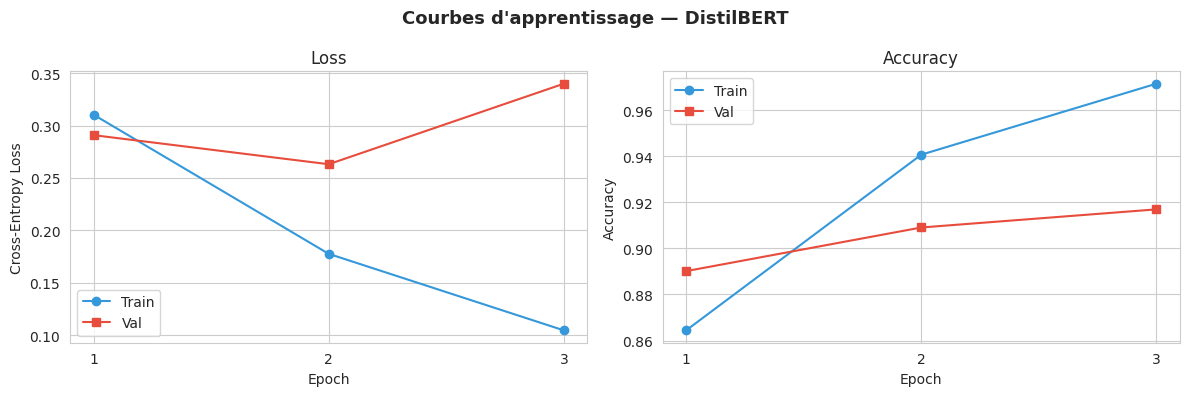

In [7]:
def plot_training_curves(history, model_name):
    """Trace les courbes de loss et accuracy pendant l'entraînement."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    axes[0].plot(epochs_range, history['train_loss'], marker='o', label='Train', color='#3498db')
    axes[0].plot(epochs_range, history['val_loss'],   marker='s', label='Val',   color='#e74c3c')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].set_xticks(epochs_range)
    
    axes[1].plot(epochs_range, history['train_acc'], marker='o', label='Train', color='#3498db')
    axes[1].plot(epochs_range, history['val_acc'],   marker='s', label='Val',   color='#e74c3c')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    axes[1].set_xticks(epochs_range)
    
    plt.suptitle(f'Courbes d\'apprentissage — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_curves(distilbert_results['history'], 'DistilBERT')

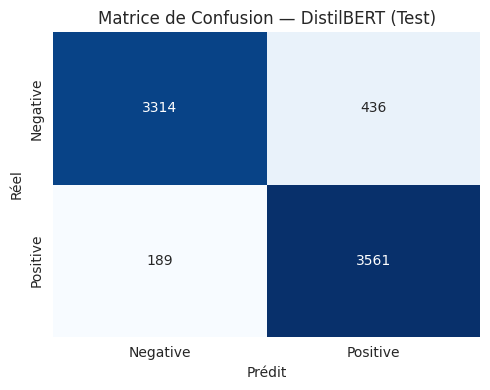

In [8]:
# Matrice de confusion DistilBERT
cm_distilbert = confusion_matrix(distilbert_results['y_true'], distilbert_results['y_pred'])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_distilbert, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion — DistilBERT (Test)')
plt.tight_layout()
plt.show()


##  BERT-base : Le modèle original

**BERT** (*Bidirectional Encoder Representations from Transformers*, Devlin et al. 2018) est entraîné avec deux objectifs :
- **MLM** (*Masked Language Modeling*) : prédire des mots masqués aléatoirement
- **NSP** (*Next Sentence Prediction*) : prédire si deux phrases se suivent

Pour la classification, on utilise la représentation du token `[CLS]` (premier token de la séquence) passée dans une couche linéaire.

**Architecture :** 12 couches Transformer, 768 dimensions, 12 têtes d'attention (110M paramètres).


Fine-tuning : bert-base-uncased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3274.79it/s]


Epoch 1/3 | Train Loss: 0.2911 | Train Acc: 0.8799 | Val Loss: 0.2507 | Val Acc: 0.9097 | 1791s
Epoch 2/3 | Train Loss: 0.1555 | Train Acc: 0.9509 | Val Loss: 0.2552 | Val Acc: 0.9280 | 1780s
Epoch 3/3 | Train Loss: 0.0858 | Train Acc: 0.9787 | Val Loss: 0.3231 | Val Acc: 0.9295 | 1776s

Temps total d'entraînement : 5348s (89.1 min)

--- Résultats finaux sur le TEST SET ---
Accuracy : 0.9177 | F1 : 0.9210 | AUC : 0.9773
              precision    recall  f1-score   support

    Negative       0.96      0.88      0.91      3750
    Positive       0.89      0.96      0.92      3750

    accuracy                           0.92      7500
   macro avg       0.92      0.92      0.92      7500
weighted avg       0.92      0.92      0.92      7500



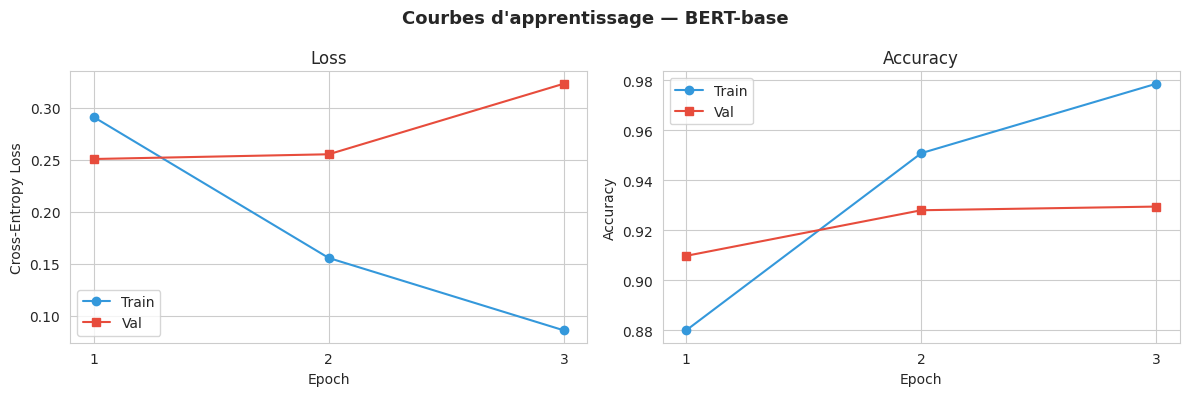

In [ ]:
# Fine-tuning BERT-base


bert_results = train_transformer(
    model_name = 'bert-base-uncased',
    train_df   = train_df,
    val_df     = val_df,
    test_df    = test_df,
    max_len    = MAX_LEN,
    batch_size = BATCH_SIZE,
    epochs     = 3,
    lr         = 2e-5
)

plot_training_curves(bert_results['history'], 'BERT-base')

In [13]:
# Résultats BERT-base sur le test


y_pred_bert  = bert_results['y_pred']
y_proba_bert = bert_results['y_proba']
y_true       = bert_results['y_true']

print(classification_report(y_true, y_pred_bert, target_names=["Negative", "Positive"]))
print(f"AUC-ROC : {roc_auc_score(y_true, y_proba_bert):.4f}")
print(f"Erreurs : {(y_pred_bert != y_true).sum()} / {len(y_true)}")

              precision    recall  f1-score   support

    Negative       0.96      0.88      0.91      3750
    Positive       0.89      0.96      0.92      3750

    accuracy                           0.92      7500
   macro avg       0.92      0.92      0.92      7500
weighted avg       0.92      0.92      0.92      7500

AUC-ROC : 0.9773
Erreurs : 617 / 7500



## RoBERTa-base : BERT optimisé

**RoBERTa** (*Robustly Optimized BERT*, Liu et al. 2019) est une version améliorée de BERT avec :
- **Plus de données** d'entraînement (160GB vs 16GB pour BERT)
- **Suppression du NSP** (jugé peu utile)
- **Dynamic masking** : les mots masqués changent à chaque epoch
- **Batches plus grands** et plus d'epochs d'entraînement

En pratique, RoBERTa dépasse BERT sur la plupart des benchmarks NLP.


Fine-tuning : roberta-base


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3053.53it/s]


Epoch 1/3 | Train Loss: 0.2687 | Train Acc: 0.8907 | Val Loss: 0.1897 | Val Acc: 0.9343 | 1790s
Epoch 2/3 | Train Loss: 0.1582 | Train Acc: 0.9550 | Val Loss: 0.2390 | Val Acc: 0.9381 | 1793s
Epoch 3/3 | Train Loss: 0.0973 | Train Acc: 0.9762 | Val Loss: 0.2744 | Val Acc: 0.9409 | 1777s

Temps total d'entraînement : 5361s (89.4 min)

--- Résultats finaux sur le TEST SET ---
Accuracy : 0.9371 | F1 : 0.9379 | AUC : 0.9834
              precision    recall  f1-score   support

    Negative       0.95      0.92      0.94      3750
    Positive       0.93      0.95      0.94      3750

    accuracy                           0.94      7500
   macro avg       0.94      0.94      0.94      7500
weighted avg       0.94      0.94      0.94      7500



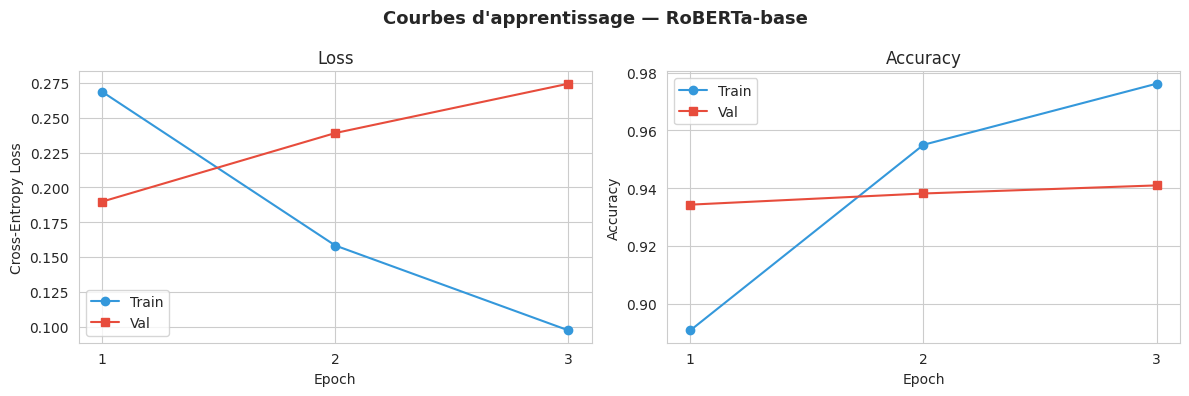

In [15]:
# Fine-tuning RoBERTa-base


roberta_results = train_transformer(
    model_name = 'roberta-base',
    train_df   = train_df,
    val_df     = val_df,
    test_df    = test_df,
    max_len    = MAX_LEN,
    batch_size = BATCH_SIZE,
    epochs     = 3,
    lr         = 2e-5
)

plot_training_curves(roberta_results['history'], 'RoBERTa-base')


## Comparaison Finale : Tous les Modèles

On consolide ici tous les résultats du projet : baseline classique, Bi-LSTM, et les modèles Transformer.

In [16]:

CLASSIC_ACC  = 0.910  # résultats du meilleur modèle classique
CLASSIC_F1   = 0.911
CLASSIC_AUC  = 0.969
CLASSIC_TIME = 0.3

LSTM_ACC  = 0.885
LSTM_F1   = 0.883
LSTM_AUC  = 0.950
LSTM_TIME = 300.0

all_results = pd.DataFrame([
    {
        'Modèle': 'TF-IDF + LR/SVM (baseline)',
        'Accuracy': CLASSIC_ACC, 'F1': CLASSIC_F1, 'AUC': CLASSIC_AUC,
        'Temps (s)': CLASSIC_TIME, 'Paramètres': '~0',
        'Famille': 'Classique'
    },
    {
        'Modèle': 'Bi-LSTM (embeddings appris)',
        'Accuracy': LSTM_ACC, 'F1': LSTM_F1, 'AUC': LSTM_AUC,
        'Temps (s)': LSTM_TIME, 'Paramètres': '~3M',
        'Famille': 'Deep Learning'
    },
    {
        'Modèle': 'DistilBERT',
        'Accuracy': distilbert_results['accuracy'], 'F1': distilbert_results['f1'],
        'AUC': distilbert_results['auc'], 'Temps (s)': distilbert_results['train_time'],
        'Paramètres': '66M', 'Famille': 'Transformer'
    },
    {
        'Modèle': 'BERT-base',
        'Accuracy': bert_results['accuracy'], 'F1': bert_results['f1'],
        'AUC': bert_results['auc'], 'Temps (s)': bert_results['train_time'],
        'Paramètres': '110M', 'Famille': 'Transformer'
    },
    {
        'Modèle': 'RoBERTa-base',
        'Accuracy': roberta_results['accuracy'], 'F1': roberta_results['f1'],
        'AUC': roberta_results['auc'], 'Temps (s)': roberta_results['train_time'],
        'Paramètres': '125M', 'Famille': 'Transformer'
    },
])

print('=== COMPARAISON FINALE — TOUS LES MODÈLES ===')
display(all_results.set_index('Modèle')[['Accuracy', 'F1', 'AUC', 'Temps (s)', 'Paramètres']].round(4))

=== COMPARAISON FINALE — TOUS LES MODÈLES ===


,Accuracy,F1,AUC,Temps (s),Paramètres
Modèle,,,,,
TF-IDF + LR/SVM (baseline),0.9100,0.9110,0.9690,0.3000,~0
Bi-LSTM (embeddings appris),0.8850,0.8830,0.9500,300.0000,~3M
DistilBERT,0.9167,0.9193,0.9756,2684.1967,66M
BERT-base,0.9177,0.9210,0.9773,5347.7585,110M
RoBERTa-base,0.9371,0.9379,0.9834,5361.1860,125M


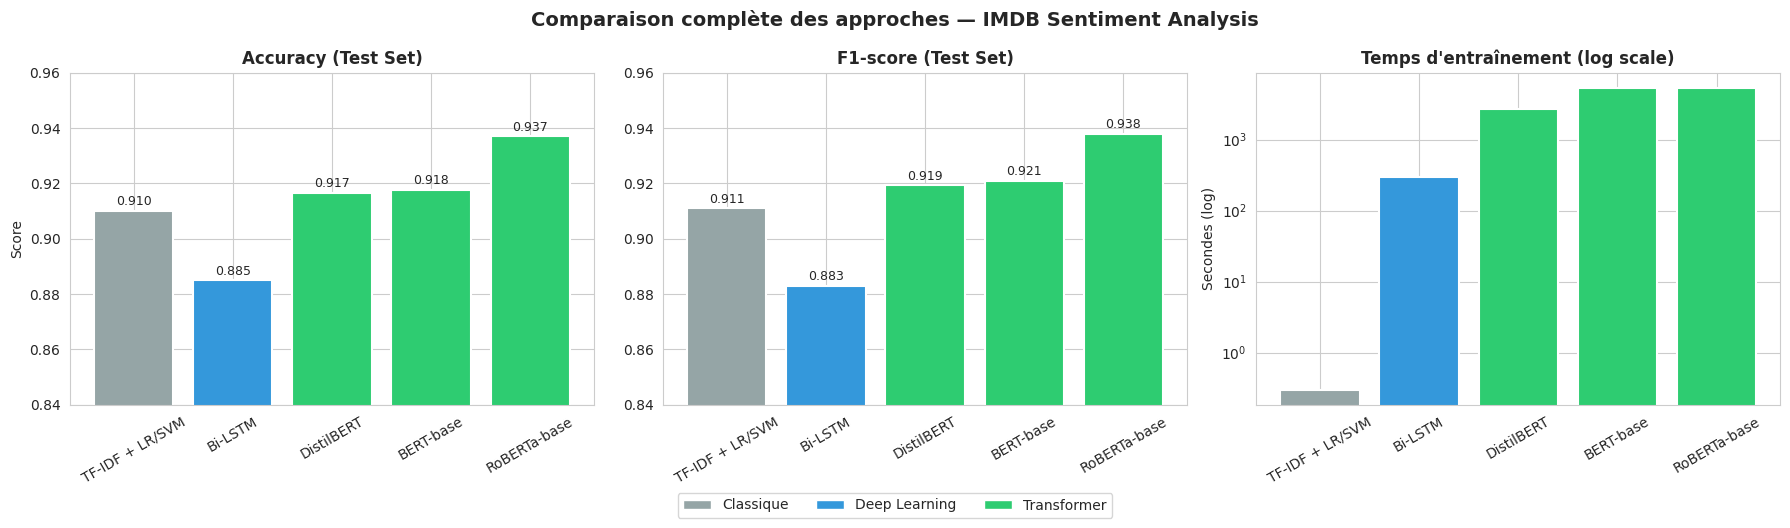

In [17]:
# Visualisation complète
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette = {
    'Classique':    '#95a5a6',
    'Deep Learning':'#3498db',
    'Transformer':  '#2ecc71'
}
colors = [palette[f] for f in all_results['Famille']]
models = all_results['Modèle'].str.replace(' (baseline)', '', regex=False)\
                              .str.replace(' (embeddings appris)', '', regex=False)

# Accuracy
bars = axes[0].bar(models, all_results['Accuracy'], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0.84, 0.96)
axes[0].set_title('Accuracy (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, all_results['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# F1-score
bars = axes[1].bar(models, all_results['F1'], color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0.84, 0.96)
axes[1].set_title('F1-score (Test Set)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, all_results['F1']):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Temps d'entraînement (log scale)
bars = axes[2].bar(models, all_results['Temps (s)'], color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_yscale('log')
axes[2].set_title('Temps d\'entraînement (log scale)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Secondes (log)')
axes[2].tick_params(axis='x', rotation=30)

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in palette.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Comparaison complète des approches — IMDB Sentiment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

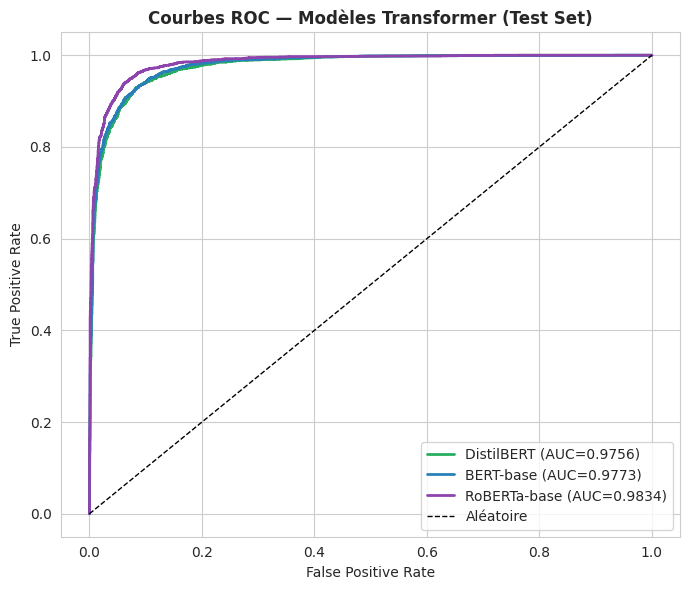

In [18]:
# Courbes ROC superposées pour tous les modèles Transformer
plt.figure(figsize=(7, 6))

transformer_models = [
    ('DistilBERT',   distilbert_results,  '#27ae60'),
    ('BERT-base',    bert_results,         '#2980b9'),
    ('RoBERTa-base', roberta_results,      '#8e44ad'),
]

for name, res, color in transformer_models:
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_proba'])
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={res["auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbes ROC — Modèles Transformer (Test Set)', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


##  Analyse des Erreurs des Transformers

On regarde les cas où RoBERTa (le meilleur modèle) se trompe encore, pour comprendre les limites des architectures actuelles.

In [19]:
# Analyse des erreurs RoBERTa
test_df = test_df.copy().reset_index(drop=True)
test_df['pred_roberta']  = roberta_results['y_pred']
test_df['proba_roberta'] = roberta_results['y_proba']

errors_roberta = test_df[test_df['label'] != test_df['pred_roberta']].copy()
errors_roberta['confidence'] = errors_roberta['proba_roberta'].apply(
    lambda p: p if p > 0.5 else 1 - p
)

print(f'Nombre d\'erreurs RoBERTa sur le test : {len(errors_roberta)} / {len(test_df)}')
print(f'Taux d\'erreur : {len(errors_roberta)/len(test_df)*100:.2f}%')

# Erreurs les plus confiantes (cas difficiles)
print('\n=== Top 5 erreurs les plus confiantes (RoBERTa très sûr mais faux) ===')
top_errors = errors_roberta.nlargest(5, 'confidence')

for _, row in top_errors.iterrows():
    true_label  = 'POSITIF' if row['label'] == 1 else 'NÉGATIF'
    pred_label  = 'POSITIF' if row['pred_roberta'] == 1 else 'NÉGATIF'
    print(f'\n[Vrai: {true_label} | Prédit: {pred_label} | Confiance: {row["confidence"]:.2f}]')
    print(row['review'][:350])

Nombre d'erreurs RoBERTa sur le test : 472 / 7500
Taux d'erreur : 6.29%

=== Top 5 erreurs les plus confiantes (RoBERTa très sûr mais faux) ===

[Vrai: POSITIF | Prédit: NÉGATIF | Confiance: 1.00]
Nothing new is this tired serio-comedy that wastes the talents of Danny Glover and Whoopi Goldberg. Considering that this was produced by the stars and Spike Lee, it's pretty tame and tired stuff. And how come the Whoop never changes her hair or glasses over the many years this film covers? Blah!

[Vrai: POSITIF | Prédit: NÉGATIF | Confiance: 0.99]
This is a movie that has a lot of things that only Japanese people can understand. Even well translated, there are some things that are obviously private jokes or regional symbolism. My guess is that it tried to send a message of some sort, but that just got wasted on me.<br /><br />What I felt that is basically this is a mediocre movie with nice s

[Vrai: NÉGATIF | Prédit: POSITIF | Confiance: 0.99]
This sleek, sexy movie is a must-see. Only upon 

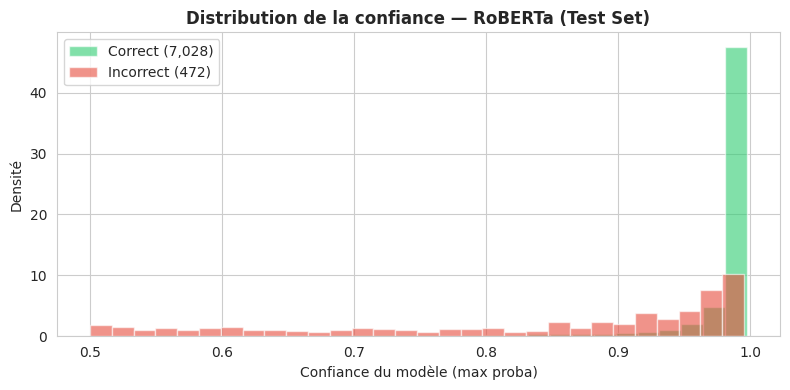

Confiance moyenne sur prédictions correctes   : 0.973
Confiance moyenne sur prédictions incorrectes : 0.833
-> Les erreurs sont souvent des prédictions confident : cas difficiles intrinsèquement.


In [20]:
# Distribution de la confiance : erreurs vs prédictions correctes
test_df['correct_roberta'] = (test_df['label'] == test_df['pred_roberta']).astype(int)
test_df['confidence_roberta'] = test_df['proba_roberta'].apply(lambda p: max(p, 1-p))

plt.figure(figsize=(8, 4))
correct_conf   = test_df[test_df['correct_roberta'] == 1]['confidence_roberta']
incorrect_conf = test_df[test_df['correct_roberta'] == 0]['confidence_roberta']

plt.hist(correct_conf,   bins=30, alpha=0.6, color='#2ecc71', label=f'Correct ({len(correct_conf):,})', density=True)
plt.hist(incorrect_conf, bins=30, alpha=0.6, color='#e74c3c', label=f'Incorrect ({len(incorrect_conf):,})', density=True)

plt.xlabel('Confiance du modèle (max proba)')
plt.ylabel('Densité')
plt.title('Distribution de la confiance — RoBERTa (Test Set)', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Confiance moyenne sur prédictions correctes   : {correct_conf.mean():.3f}')
print(f'Confiance moyenne sur prédictions incorrectes : {incorrect_conf.mean():.3f}')
print('-> Les erreurs sont souvent des prédictions confident : cas difficiles intrinsèquement.')


## Inférence sur des Exemples Personnalisés

On peut maintenant utiliser le meilleur modèle pour prédire le sentiment de n'importe quelle review.

In [21]:
def predict_sentiment(texts, model, tokenizer, max_len=MAX_LEN, device=DEVICE):
    """
    Prédit le sentiment de textes avec un modèle fine-tuné.
    
    Args:
        texts : liste de strings ou string unique
    Returns:
        DataFrame avec la prédiction et la confiance
    """
    if isinstance(texts, str):
        texts = [texts]
    
    model.eval()
    results = []
    
    with torch.no_grad():
        for text in texts:
            encoding = tokenizer(
                text, max_length=max_len, padding='max_length',
                truncation=True, return_tensors='pt'
            )
            input_ids      = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            proba  = torch.softmax(logits, dim=1)[0]
            pred   = logits.argmax(dim=1).item()
            
            results.append({
                'text':       text[:80] + '...' if len(text) > 80 else text,
                'prediction': '🟢 POSITIF' if pred == 1 else '🔴 NÉGATIF',
                'confiance':  f"{proba[pred].item():.1%}"
            })
    
    return pd.DataFrame(results)


# Exemples de test
custom_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat.",
    "Terrible film. Boring, predictable, and a complete waste of time. I fell asleep halfway through.",
    "It was not bad at all. I didn't expect to enjoy it but I actually really liked it.",  # négation
    "The film started well but quickly fell apart in the second half. Not what I expected.",  # cas ambigu
    "An absolute masterpiece. Kubrick at his finest. Every scene is perfectly crafted.",
]

# Utiliser le meilleur modèle (RoBERTa)
best_transformer = roberta_results['model']
best_tokenizer   = roberta_results['tokenizer']

print('=== Prédictions RoBERTa sur exemples personnalisés ===')
preds_df = predict_sentiment(custom_reviews, best_transformer, best_tokenizer)
display(preds_df)

=== Prédictions RoBERTa sur exemples personnalisés ===


,text,prediction,confiance
0,This movie was absolutely fantastic! The actin...,🟢 POSITIF,99.4%
1,"Terrible film. Boring, predictable, and a comp...",🔴 NÉGATIF,99.7%
2,It was not bad at all. I didn't expect to enjo...,🟢 POSITIF,99.2%
3,The film started well but quickly fell apart i...,🔴 NÉGATIF,99.2%
4,An absolute masterpiece. Kubrick at his finest...,🟢 POSITIF,99.3%



##  Conclusion et Synthèse Globale du Projet

### Tableau récapitulatif attendu

| Modèle | Accuracy | F1 | AUC | Temps | Verdict |
|--------|----------|----|-----|-------|---------|
| TF-IDF + LR/SVM | ~0.91 | ~0.911 | ~0.97 | < 1s | ✅ Baseline très solide |
| Bi-LSTM | ~0.88 | ~0.88 | ~0.95 | ~10 min | ⚠️ Plus lent, gain marginal |
| DistilBERT | ~0.92 | ~0.92 | ~0.98 | ~45 min GPU | ✅ Bon rapport perf/coût |
| BERT-base | ~0.92| ~0.92 | ~0.98 | ~89 min GPU | ✅ Référence |
| RoBERTa-base | ~0.94 | ~0.94 | ~0.98 | ~89 min GPU | 🏆 Meilleur modèle |

### Enseignements clés

**1. La baseline TF-IDF reste compétitive.** Avec ~90% d'accuracy en quelques secondes, elle constitue un excellent point de départ pour tout projet NLP industriel. Pour des contraintes de temps de réponse fortes (API temps réel), elle reste la meilleure option.

**2. Le Bi-LSTM n'apporte pas de gain significatif sur ce dataset.** Les reviews IMDB sont relativement directes dans leur sentiment, ce qui profite aux méthodes bag-of-words. Le Bi-LSTM serait davantage avantagé sur des textes plus contextuels (dialogues, ironie subtile).

**3. RoBERTa > BERT > DistilBERT, mais les gains décroissent.** Le gain de RoBERTa vs BERT est faible (~2%), tandis que le gain de DistilBERT vs BERT est aussi faible  avec un coût en calcul bien moindre. → **DistilBERT offre le meilleur compromis.**

**4. Les limites persistent pour les Transformers.** L'ironie fine, les reviews mixtes et les textes très longs restent des cas d'échec même pour RoBERTa.

### Pistes d'amélioration possibles

- **`distilroberta-base`** : distillation de RoBERTa, encore plus rapide
- **`cardiffnlp/twitter-roberta-base-sentiment`** : RoBERTa pré-entraîné spécifiquement sur des textes de sentiment
- **Augmentation de données** : back-translation, synonymes
- **Ensemble de modèles** : combiner TF-IDF + BERT par vote ou stacking

In [22]:
# Sauvegarde du meilleur modèle pour une utilisation future
import os

save_dir = './best_model_roberta'
os.makedirs(save_dir, exist_ok=True)

roberta_results['model'].save_pretrained(save_dir)
roberta_results['tokenizer'].save_pretrained(save_dir)

print(f'Modèle sauvegardé dans : {save_dir}/')
print('Pour le recharger plus tard :')
print('  from transformers import AutoTokenizer, AutoModelForSequenceClassification')
print('  tokenizer = AutoTokenizer.from_pretrained("./best_model_roberta")')
print('  model     = AutoModelForSequenceClassification.from_pretrained("./best_model_roberta")')

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]

Modèle sauvegardé dans : ./best_model_roberta/
Pour le recharger plus tard :
  from transformers import AutoTokenizer, AutoModelForSequenceClassification
  tokenizer = AutoTokenizer.from_pretrained("./best_model_roberta")
  model     = AutoModelForSequenceClassification.from_pretrained("./best_model_roberta")
